In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
gene_weights = pd.read_csv("semantics.csv", index_col=0)
topic_names = pd.read_csv("claude_yeast_topic_labels.csv", index_col=0)
gene_clusters = pd.read_csv("classical_ts__s__gmm_clustered__visible_signal.csv", index_col=0)

In [4]:
display(gene_weights, gene_clusters, topic_names)

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
10001_at,0.001111,0.460798,0.031914,0.022387,0.204904,0.001112,0.001111,0.274440,0.001111,0.001112
10003_f_at,0.976922,0.002564,0.002564,0.002564,0.002564,0.002564,0.002564,0.002564,0.002564,0.002564
10005_at,0.000556,0.000556,0.474006,0.085148,0.000556,0.208245,0.027301,0.157477,0.000556,0.045600
10010_at,0.000763,0.000763,0.754662,0.000763,0.000763,0.000763,0.151174,0.088820,0.000763,0.000763
10011_at,0.014286,0.014286,0.014286,0.014286,0.871421,0.014286,0.014287,0.014289,0.014286,0.014286
...,...,...,...,...,...,...,...,...,...,...
9992_at,0.001493,0.001493,0.001493,0.191895,0.001493,0.796162,0.001493,0.001493,0.001493,0.001494
9994_at,0.978048,0.002439,0.002439,0.002439,0.002439,0.002439,0.002439,0.002439,0.002439,0.002439
9996_at,0.357919,0.003847,0.318914,0.003847,0.237957,0.003847,0.062129,0.003846,0.003847,0.003847
9998_at,0.002000,0.186495,0.036484,0.070701,0.002001,0.694318,0.002000,0.002000,0.002000,0.002000


,labels,probabilities
10001_at,7,0.857061
10003_f_at,3,0.999703
10005_at,3,0.997951
10010_at,5,0.986816
10011_at,7,0.701117
...,...,...
9992_at,0,0.993806
9994_at,3,0.998811
9996_at,2,0.966032
9998_at,2,0.993418


,Short Name,Long Description
Topic,,
Topic 1,Cytoplasmic Translation & Ribosome Structure,Genes encoding structural constituents and ass...
Topic 2,Cell Cycle & DNA Damage Checkpoint Kinases,Serine/threonine kinases and their regulators ...
Topic 3,Proteasome & ATP-Dependent Protein Degradation,Genes encoding components of the ubiquitin-pro...
Topic 4,RNA Polymerase II Transcription & Chromatin Re...,Genes involved in RNA Pol II-mediated transcri...
Topic 5,ER Membrane & Uncharacterized Transmembrane Pr...,"Integral membrane proteins (GO:0016021, GO:001..."
Topic 6,Mitotic/Meiotic Chromosome Segregation & Nucle...,"Genes associated with spindle pole body, kinet..."
Topic 7,Mitochondrial Metabolism & Oxidative Phosphory...,Genes encoding proteins of the mitochondrial i...
Topic 8,Vesicular Transport & Endomembrane System,Genes mediating intracellular transport (GO:00...
Topic 9,Retrotransposon Biology (Ty Elements) & Nuclei...,Genes derived from or associated with yeast Ty...


In [ ]:
# get most likely topics for each gene/transcript
# most_likely_topic = [f"Topic {i+1}" for i in gene_weights.values.argmax(axis=1)]
most_likely_topic = gene_weights.values.argmax(axis=1)
display(most_likely_topic)

# correlate these with clusters
gene_clusters["topic"] = most_likely_topic

display(gene_clusters)

array([1, 0, 2, ..., 0, 5, 7])

,labels,probabilities,topic
10001_at,7,0.857061,1
10003_f_at,3,0.999703,0
10005_at,3,0.997951,2
10010_at,5,0.986816,2
10011_at,7,0.701117,4
...,...,...,...
9992_at,0,0.993806,5
9994_at,3,0.998811,0
9996_at,2,0.966032,0
9998_at,2,0.993418,5


array([[7, 1],
       [3, 0],
       [3, 2],
       ...,
       [2, 0],
       [2, 5],
       [5, 7]])

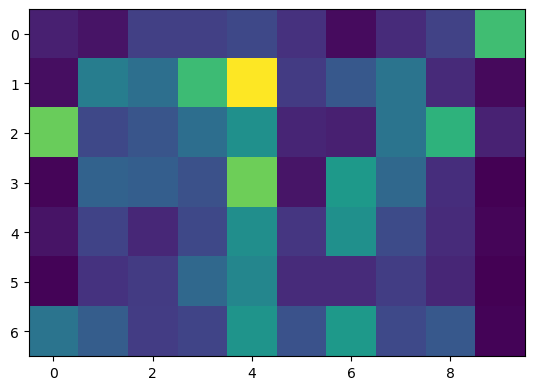

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

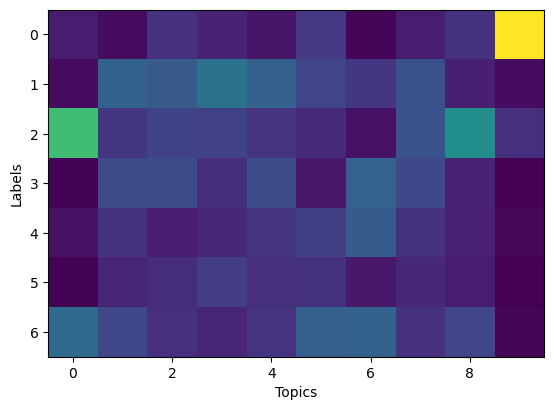

In [32]:
# get a number of counts of each
labtop = gene_clusters[["labels", "topic"]].values

labs_gap_uniq = np.sort(np.unique(labtop[:, 0]))
tops_uniq = np.sort(np.unique(labtop[:, 1]))
labnum = len(labs_gap_uniq)
topnum = len(tops_uniq)

labidxdict = dict(zip(labs_gap_uniq, np.arange(labnum)))

tops = labtop[:, 1].copy()
labs = np.array([labidxdict[lab] for lab in labtop[:, 0]])

X = np.zeros((labnum, topnum))
for lab, top in zip(labs, tops):
    X[lab, top] += 1

plt.imshow(X)
plt.show()


plt.imshow(X / np.sum(X, axis=0))
plt.ylabel("Labels")
plt.xlabel("Topics")

display(np.sum(X / np.sum(X, axis=0), axis=0))

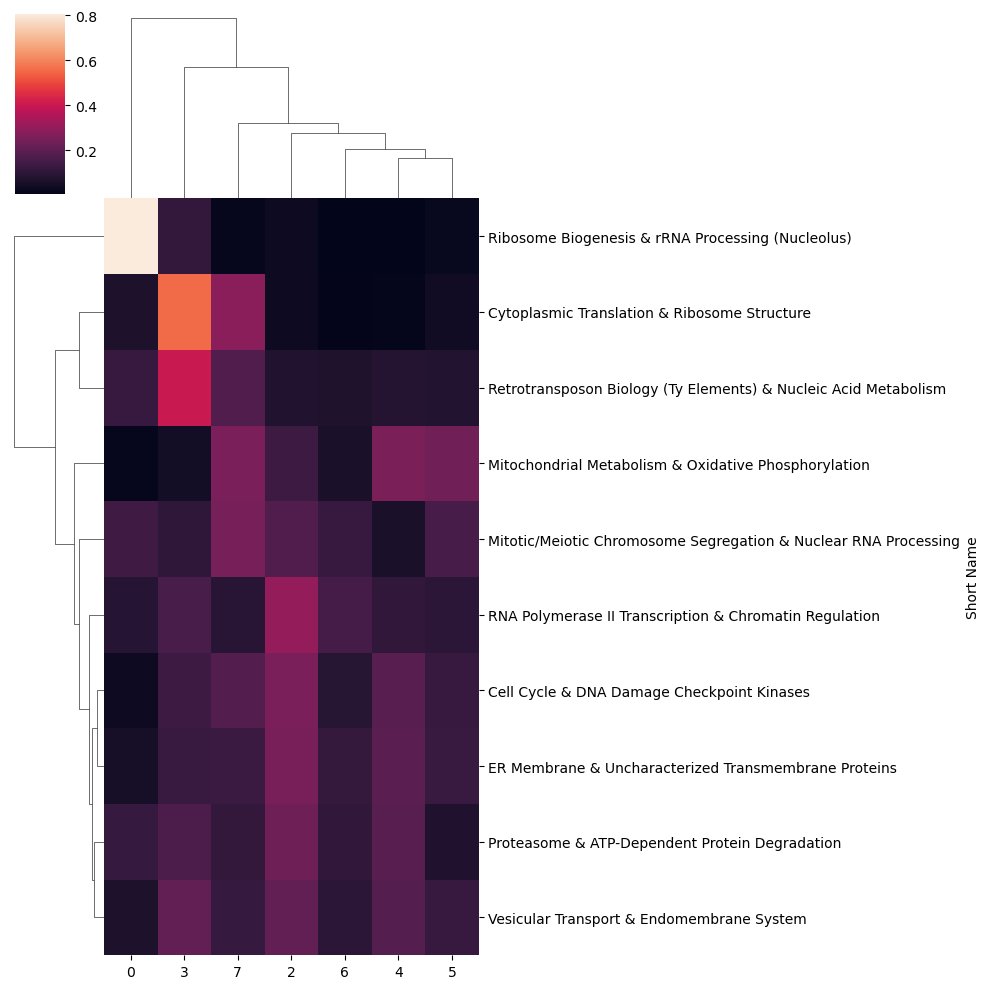

In [40]:
# c = sns.clustermap(pd.DataFrame(X / np.sum(X, axis=0), index=np.arange(labnum), columns=np.arange(topnum)))
c = sns.clustermap(pd.DataFrame(X / np.sum(X, axis=0), index=labs_gap_uniq, columns=topic_names["Short Name"]).T)
# c.ax_heatmap.set_xticklabels()
# c.ax_heatmap.set_yticklabels()

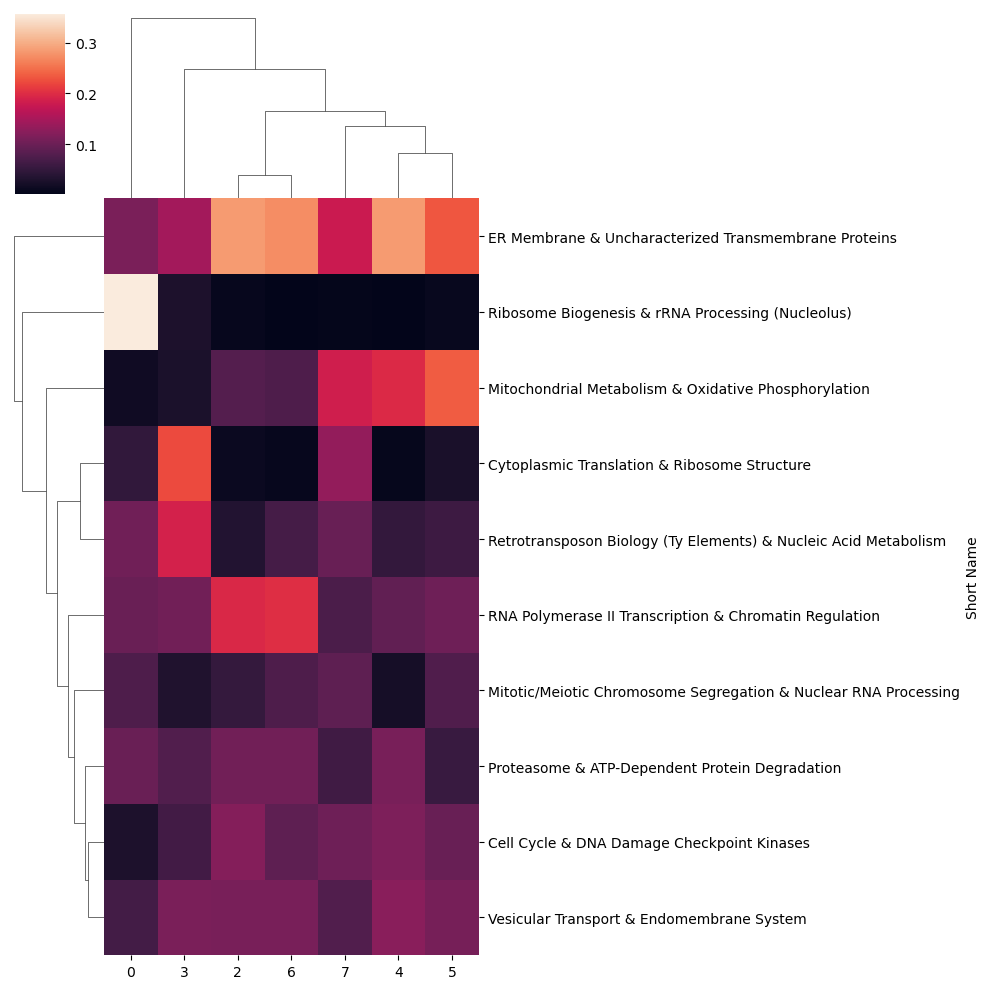

In [41]:
c = sns.clustermap(pd.DataFrame((X.T / np.sum(X, axis=1)).T, index=labs_gap_uniq, columns=topic_names["Short Name"]).T)


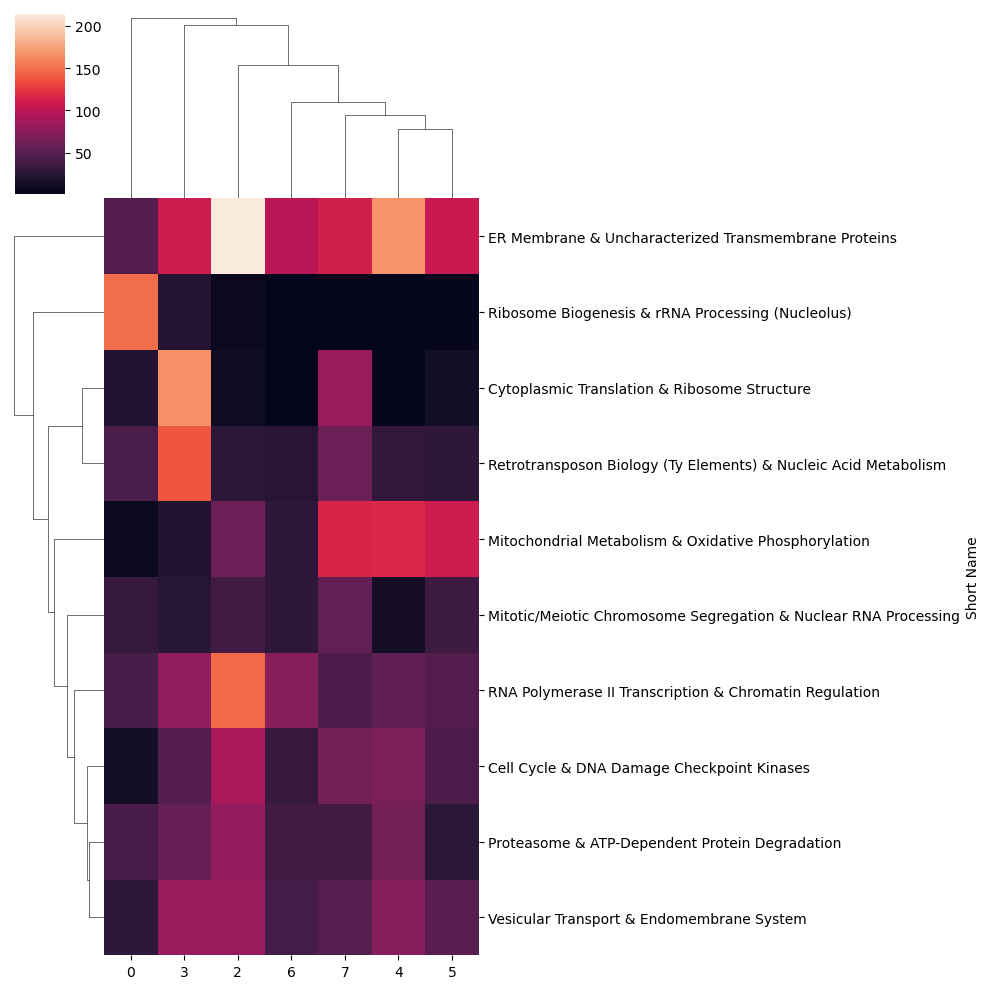

In [42]:
c = sns.clustermap(pd.DataFrame(X, index=labs_gap_uniq, columns=topic_names["Short Name"]).T)


/tmp/ipykernel_1889762/2700071843.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = sns.heatmap(pd.DataFrame(Xperm / np.sum(Xperm, axis=0), index=labs_gap_uniq[[0, 2, 6, 4, 3, 1, 5]], columns=topic_names["Short Name"][[1, 2, 3, 4, 5, 6, 7, 8, 0, 9]]).T)


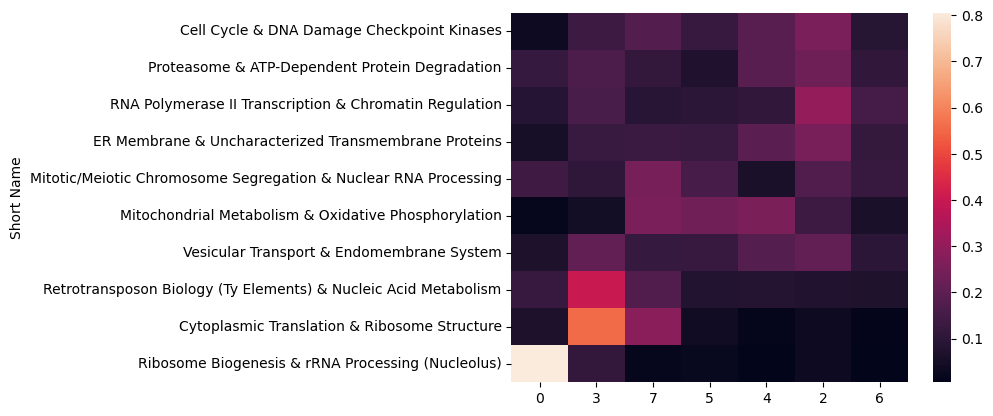

In [48]:
# sort up
Xperm = X[[0, 2, 6, 4, 3, 1, 5]]
Xperm = Xperm[:, [1, 2, 3, 4, 5, 6, 7, 8, 0, 9]]

# c = sns.clustermap(pd.DataFrame(X / np.sum(X, axis=0), index=np.arange(labnum), columns=np.arange(topnum)))
c = sns.heatmap(pd.DataFrame(Xperm / np.sum(Xperm, axis=0), index=labs_gap_uniq[[0, 2, 6, 4, 3, 1, 5]], columns=topic_names["Short Name"][[1, 2, 3, 4, 5, 6, 7, 8, 0, 9]]).T)
# c.ax_heatmap.set_xticklabels()
# c.ax_heatmap.set_yticklabels()

/tmp/ipykernel_1889762/3465481954.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = sns.heatmap(pd.DataFrame((Xperm.T / np.sum(Xperm, axis=1)).T, index=labs_gap_uniq[[0, 2, 6, 4, 3, 1, 5]], columns=topic_names["Short Name"][[1, 2, 3, 4, 5, 6, 7, 8, 0, 9]]).T)


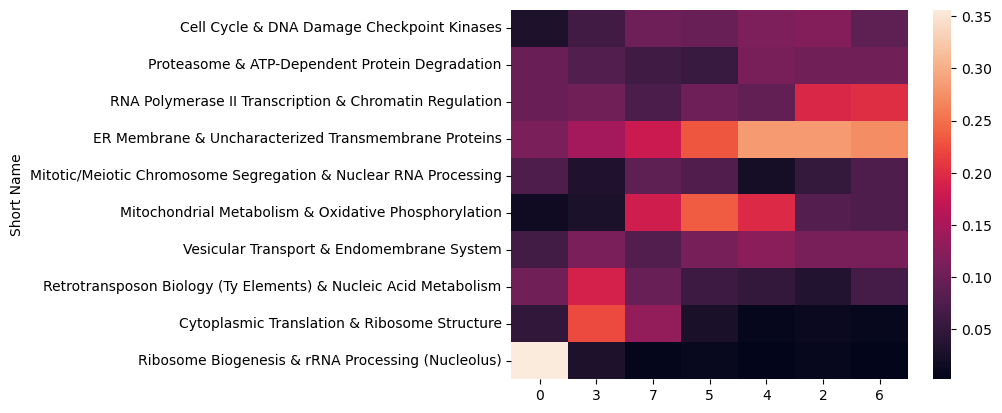

In [49]:
# sort up
Xperm = X[[0, 2, 6, 4, 3, 1, 5]]
Xperm = Xperm[:, [1, 2, 3, 4, 5, 6, 7, 8, 0, 9]]

# c = sns.clustermap(pd.DataFrame(X / np.sum(X, axis=0), index=np.arange(labnum), columns=np.arange(topnum)))
c = sns.heatmap(pd.DataFrame((Xperm.T / np.sum(Xperm, axis=1)).T, index=labs_gap_uniq[[0, 2, 6, 4, 3, 1, 5]], columns=topic_names["Short Name"][[1, 2, 3, 4, 5, 6, 7, 8, 0, 9]]).T)
# c.ax_heatmap.set_xticklabels()
# c.ax_heatmap.set_yticklabels()